In [19]:
import random
random.seed(42)

In [20]:
import os
import pandas as pd
import numpy as np
import shutil
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.metrics import average_precision_score
from optuna.importance import get_param_importances
from optuna.importance import MeanDecreaseImpurityImportanceEvaluator
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import pickle
import re

import lightgbm as lgb
import optuna

# Dataset loading + processing (from prev notebooks)

In [21]:
sns.set_theme(style="whitegrid", palette="rocket")

In [22]:
df=pd.read_csv('/kaggle/input/processed-sepsis-dataset/processed_dataset_v2.psv', sep="|")
df_col = df.columns.tolist()
df_col.remove('id')
df_col.remove('SepsisLabel')
df = df.sort_values(['id', 'ICULOS'])
ids = df['id'].unique()

In [23]:
feature_imp=pd.read_csv('/kaggle/input/datasets/annarechkalova/importance-lgbm/importance_lgbm (2).csv')
feature_imp = feature_imp.sort_values(by='Gain', ascending=False).reset_index(drop=True)
feature_imp['Cumulative_Gain'] = feature_imp['Gain'].cumsum() / feature_imp['Gain'].sum()
top_features = feature_imp[feature_imp['Cumulative_Gain'] <= 0.99]
top_features.to_csv("features_lgbm.csv")

In [24]:
df = df.sort_values(['id', 'ICULOS'])

ids = df['id'].unique()

ratio = 0.15 / 0.90

train_val_ids, test_ids = train_test_split(ids, test_size=0.10, random_state=42)

train_ids, val_ids = train_test_split(train_val_ids, test_size=ratio, random_state=42)

print(f"{set(train_ids) & set(val_ids)}")
print(f"{set(train_ids) & set(test_ids)}")
print(f"{set(val_ids) & set(test_ids)}")

total = len(ids)
print(f"\nTrain: {len(train_ids)/total:.2%}")
print(f"Val:   {len(val_ids)/total:.2%}")
print(f"Test:  {len(test_ids)/total:.2%}")

train_df = df[df['id'].isin(train_ids)]
val_df = df[df['id'].isin(val_ids)]
test_df = df[df['id'].isin(test_ids)]

set()
set()
set()

Train: 75.00%
Val:   15.00%
Test:  10.00%


In [25]:
X_train = train_df[top_features['Feature']]
y_train = train_df['SepsisLabel']

X_val = val_df[top_features['Feature']]
y_val = val_df['SepsisLabel']

X_test = test_df[top_features['Feature']]
y_test = test_df['SepsisLabel']

In [26]:
train_df

,id,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,...,Resp_Max_3h,Resp_Mean_3h,Resp_Std_3h,Resp_Max_6h,Resp_Mean_6h,Resp_Std_6h,Resp_Min_12h,Resp_Max_12h,Resp_Mean_12h,Resp_Std_12h
77,p000003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
78,p000003,87.0,96.0,NaN,131.0,70.33,NaN,29.0,NaN,NaN,...,29.0,29.000000,NaN,29.0,29.000000,NaN,29.0,29.0,29.000000,NaN
79,p000003,93.0,97.0,37.11,130.0,69.33,NaN,40.0,NaN,NaN,...,40.0,34.500000,7.778175,40.0,34.500000,7.778175,29.0,40.0,34.500000,7.778175
80,p000003,90.0,95.0,37.11,128.0,69.33,NaN,23.0,NaN,NaN,...,40.0,30.666667,8.621678,40.0,30.666667,8.621678,23.0,40.0,30.666667,8.621678
81,p000003,89.0,97.0,37.11,137.0,62.67,50.0,26.0,NaN,NaN,...,40.0,29.666667,9.073772,40.0,29.500000,7.416198,23.0,40.0,29.500000,7.416198
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1552205,p120000,80.0,96.0,36.40,115.0,87.00,65.0,15.0,NaN,NaN,...,16.0,15.333333,0.577350,18.0,16.000000,1.095445,15.0,18.0,16.416667,1.240112
1552206,p120000,74.0,97.0,36.40,114.0,83.00,67.0,15.0,NaN,NaN,...,15.0,15.000000,0.000000,18.0,15.833333,1.169045,15.0,18.0,16.166667,1.193416
1552207,p120000,78.0,98.0,36.40,110.0,83.00,69.0,15.0,NaN,NaN,...,15.0,15.000000,0.000000,16.0,15.333333,0.516398,15.0,18.0,16.083333,1.240112
1552208,p120000,82.0,99.0,36.60,124.0,91.00,71.0,16.0,NaN,NaN,...,16.0,15.333333,0.577350,16.0,15.333333,0.516398,15.0,18.0,16.166667,1.193416


In [27]:
top_features

,Unnamed: 0,Gain,Feature,Cumulative_Gain
0,0,1.818719e+06,ICULOS,0.424695
1,1,3.705369e+05,FiO2_Freq_6h,0.511220
2,2,1.074633e+05,Unit1,0.536314
3,3,1.031112e+05,Temp_Max_6h,0.560392
4,4,1.011282e+05,Alkalinephos,0.584006
...,...,...,...,...
117,117,2.154528e+03,FiO2_Mean_6h,0.988054
118,118,2.121450e+03,Alkalinephos_Freq_12h,0.988549
119,119,2.030557e+03,DBP_Std_12h,0.989023
120,120,2.013140e+03,Gender,0.989493


In [28]:
selected_features = top_features['Feature'].tolist()

In [29]:
df_col_originals = [c for c in selected_features
                    if not c.endswith('_missing')
                    and not re.search(r'_\d+h$', c)]

In [30]:
df_new = df[df_col]

In [31]:
import pickle

model_path = '/kaggle/input/models/annarechkalova/lightgbm-sepsis/pytorch/default/4/lgbm_sepsis_model.pkl'
with open(model_path, 'rb') as f:
    try:
        model = pickle.load(f)
    except EOFError:
        print("error with loading")

In [32]:
print(f"Num of features: {len(top_features)}")

Num of features: 122


# SHAP

In [33]:
import shap
explainer = shap.TreeExplainer(model)

In [34]:
shap.initjs()

In [35]:
shap_values = explainer.shap_values(X_test)
mean_shap = np.abs(shap_values).mean(axis=0)

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


In [36]:
shap_df = pd.DataFrame({
    'feature': X_test.columns,
    'mean_shap': mean_shap
})

In [37]:
mean_shap

array([2.95922461e-01, 2.68822535e-01, 1.46092459e-01, 6.08475848e-02,
       4.76173500e-02, 8.07199574e-02, 2.01407424e-01, 3.09698633e-02,
       1.09895471e-01, 1.10756505e-01, 5.95930833e-02, 1.43767059e-02,
       3.01257613e-02, 8.32256514e-02, 1.20142318e-01, 2.41883923e-02,
       5.21945480e-02, 2.08370204e-02, 6.05278774e-02, 4.94800524e-02,
       9.74728693e-03, 2.27247432e-02, 1.89688144e-02, 1.80572946e-02,
       5.49084637e-02, 2.56814309e-02, 4.86396498e-02, 3.38213202e-02,
       5.84018318e-03, 1.54532186e-02, 4.60614466e-02, 1.55191750e-02,
       7.98282132e-03, 3.65638844e-02, 9.34133696e-03, 1.86174148e-02,
       1.78833429e-02, 6.29931874e-03, 1.81455053e-02, 1.42420810e-04,
       2.42428388e-03, 7.18053652e-03, 8.65879980e-03, 1.63193611e-02,
       1.11648944e-02, 7.45022434e-03, 8.47018927e-03, 3.77271049e-02,
       3.33700472e-02, 1.98738558e-02, 7.87210203e-03, 6.25817085e-03,
       8.30924893e-03, 1.14129257e-02, 1.21502426e-02, 5.20181633e-02,
      

In [38]:
colors_v1 = {
    'frequency': '#F1A208',
    'window': '#06A77D',
    'missingness': '#037D7A',
    'raw': '#052F5F',
}

def get_color_v1(feature_name):
    if '_Freq_' in feature_name:
        return colors_v1['frequency']
    elif '_missing' in feature_name:
        return colors_v1['missingness']
    elif any(x in feature_name for x in ['_Min_', '_Max_', '_Mean_', '_Std_']):
        return colors_v1['window']
    else:
        return colors_v1['raw']

colors_v2 = {
    'engineered': '#F1A208',
    'missingness': '#06A77D',
    'raw': '#052F5F',
}

def get_color_v2(feature_name):
    if '_Freq_' in feature_name or any(x in feature_name for x in ['_Min_', '_Max_', '_Mean_', '_Std_']):
        return colors_v2['engineered']
    elif '_missing' in feature_name:
        return colors_v2['missingness']
    else:
        return colors_v2['raw']

In [39]:
def plot_global_shap(df, color_func, colors_dict, filename):
    top20 = df.nlargest(20, 'mean_shap').sort_values('mean_shap')
    features = list(top20['feature'])
    values = list(top20['mean_shap'])
    colors = [color_func(f) for f in features]

    plt.rcParams.update({
        'font.size': 10,
        'font.family': 'sans-serif',
        'font.weight': 'normal',
        'axes.labelweight': 'normal'
    })

    fig, ax = plt.subplots(figsize=(10, 6), facecolor='white')
    bars = ax.barh(features, values, color=colors, edgecolor='#333333', linewidth=0.6)
    for bar in bars:
        width = bar.get_width()
        ax.text(width + 0.001, bar.get_y() + bar.get_height()/2,
                f'+{width:.3f}', va='center', fontsize=9, color='black')

    ax.set_xlabel('Mean |SHAP value|', fontsize=11, labelpad=10, color='black')
    ax.set_ylabel('Features', fontsize=11, labelpad=5, color='black')

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    ax.spines['left'].set_color('black')
    ax.spines['left'].set_linewidth(1.0)
    ax.spines['bottom'].set_color('black')
    ax.spines['bottom'].set_linewidth(1.0)

    ax.tick_params(axis='both', which='major', colors='black', labelsize=10)

    ax.grid(True, axis='x', linestyle='-', color='black', alpha=0.08, linewidth=0.5)
    ax.set_axisbelow(True)

    legend = [Patch(color=v, label=k) for k, v in colors_dict.items()]
    ax.legend(handles=legend, loc='lower right', frameon=True, edgecolor='black', fontsize=9)
    plt.tight_layout()
    plt.savefig(filename, bbox_inches='tight', dpi=300)
    plt.show()

## Global SHAP (mean)

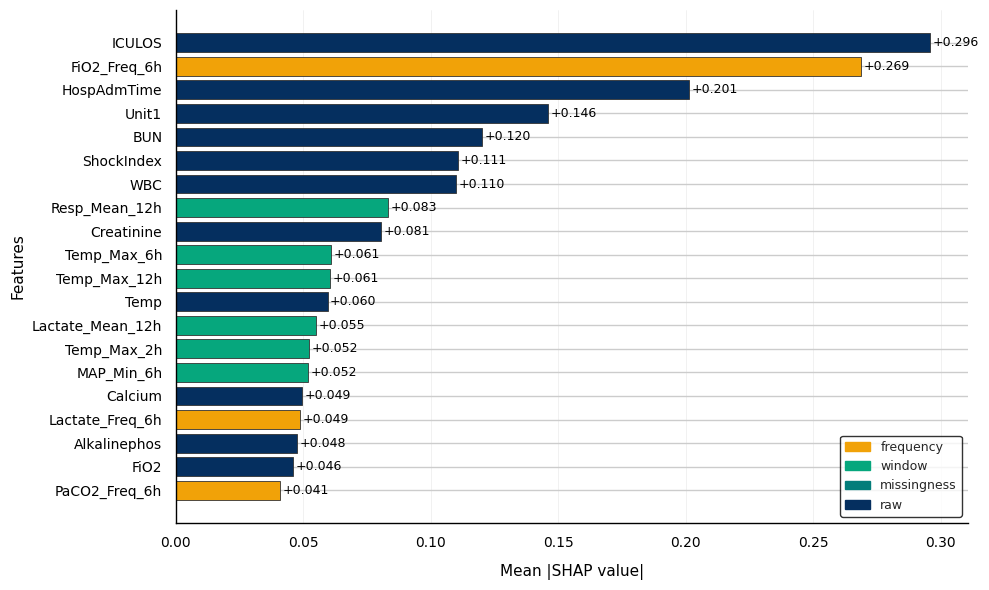

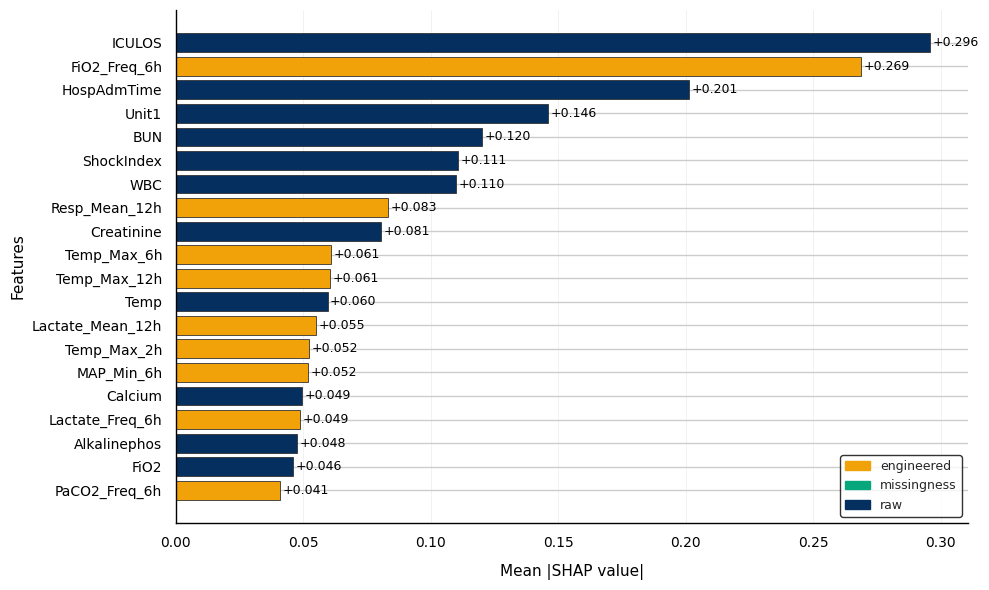

In [40]:
plot_global_shap(shap_df, get_color_v1, colors_v1, 'shap_v1.svg')
plot_global_shap(shap_df, get_color_v2, colors_v2, 'shap_v2.svg')

## Local SHAP for septic & non-septic patients

In [41]:
patient_septic_df = df[df['id'] == "p000161"]
patient_non_septic_df = df[df['id'] == "p000001"]

In [42]:
patient_septic = patient_septic_df[selected_features]
patient_non_septic = patient_non_septic_df[selected_features]

In [43]:
preds_septic = model.predict(patient_septic)
preds_non_septic = model.predict(patient_non_septic)

In [44]:
preds_septic

array([0.08859262, 0.05309048, 0.04722255, 0.15268306, 0.20954685,
       0.21044959, 0.23990151, 0.23501238, 0.24085856, 0.24618587,
       0.23689588, 0.22314385, 0.21589547, 0.21632116, 0.19689902,
       0.1969848 , 0.22899669, 0.21872865, 0.24961278, 0.59992854,
       0.55629348, 0.58054455, 0.4004132 ])

In [45]:
preds_non_septic

array([0.16000826, 0.12790913, 0.14574551, 0.13674667, 0.25927466,
       0.28763093, 0.24743018, 0.27216334, 0.25047315, 0.19839303,
       0.11781502, 0.10233774, 0.11573665, 0.1295489 , 0.09253076,
       0.08813377, 0.0269759 , 0.03204079, 0.02986232, 0.02435485,
       0.02629343, 0.02180393, 0.01798802, 0.02972607, 0.02997188,
       0.0301093 , 0.02612628, 0.02883304, 0.02994004, 0.0241306 ,
       0.02067859, 0.02562703, 0.04425851, 0.04322196, 0.05736967,
       0.04198791, 0.04368727, 0.07345318, 0.05531611, 0.07292142,
       0.06195611, 0.11254808, 0.10770828, 0.10062829, 0.25673335,
       0.25261748, 0.20667164, 0.2230061 , 0.40351889, 0.41781108,
       0.4072241 , 0.40576321, 0.46990318, 0.45481578])

In [46]:
def make_results_df(patient_df, patient_id, model, threshold):
    patient_X = patient_df[selected_features]
    probs = model.predict(patient_X)
    preds = (probs >= threshold).astype(int)
    
    results = pd.DataFrame({
        'Real Label': patient_df['SepsisLabel'].values.astype(int),
        'Probability': probs.round(4),
        'Prediction': preds,
    })
    results.index = range(1, len(results) + 1)
    results.index.name = 'Hour'
    return results

In [47]:
threshold = 0.21

results_septic = make_results_df(patient_septic_df, "p000161", model, threshold)
results_non_septic = make_results_df(patient_non_septic_df, "p000001", model, threshold)

In [48]:
results_septic

,Real Label,Probability,Prediction
Hour,,,
1,0,0.0886,0
2,0,0.0531,0
3,0,0.0472,0
4,0,0.1527,0
5,0,0.2095,0
6,0,0.2104,1
7,0,0.2399,1
8,0,0.2350,1
9,0,0.2409,1


In [49]:
results_non_septic

,Real Label,Probability,Prediction
Hour,,,
1,0,0.1600,0
2,0,0.1279,0
3,0,0.1457,0
4,0,0.1367,0
5,0,0.2593,1
6,0,0.2876,1
7,0,0.2474,1
8,0,0.2722,1
9,0,0.2505,1


In [50]:
def plot_shap_heatmap(shap_values, patient_id="", top_k=20, show_missing=True, show_windows=True, filename=None):
    values = shap_values.values
    all_names = shap_values.feature_names

    idx = list(range(len(all_names)))
    
    if not show_missing:
        idx = [i for i in idx if '_missing' not in all_names[i]]
    
    if not show_windows:
        idx = [i for i in idx if not re.search(r'_\d+h$', all_names[i])]

    values = values[:, idx]
    feature_names = [all_names[i] for i in idx]

    mean_abs = np.abs(values).mean(axis=0)
    top_idx = np.argsort(mean_abs)[::-1][:top_k]
    top_names = [feature_names[i] for i in top_idx]
    top_values = values[:, top_idx].T 
    
    fig, ax = plt.subplots(figsize=(20, top_k * 0.4 + 2))
    sns.heatmap(top_values, ax=ax,
                xticklabels=range(1, values.shape[0] + 1),
                yticklabels=top_names)
    ax.set_title(f'SHAP Heatmap — Patient {patient_id}')
    ax.set_xlabel('Hour (ICULOS)')
    plt.tight_layout()
    if filename:
        plt.savefig(filename, bbox_inches='tight', dpi=300, facecolor='white')
    plt.show()

### Septic patient p000161

In [51]:
sv = explainer(patient_septic)

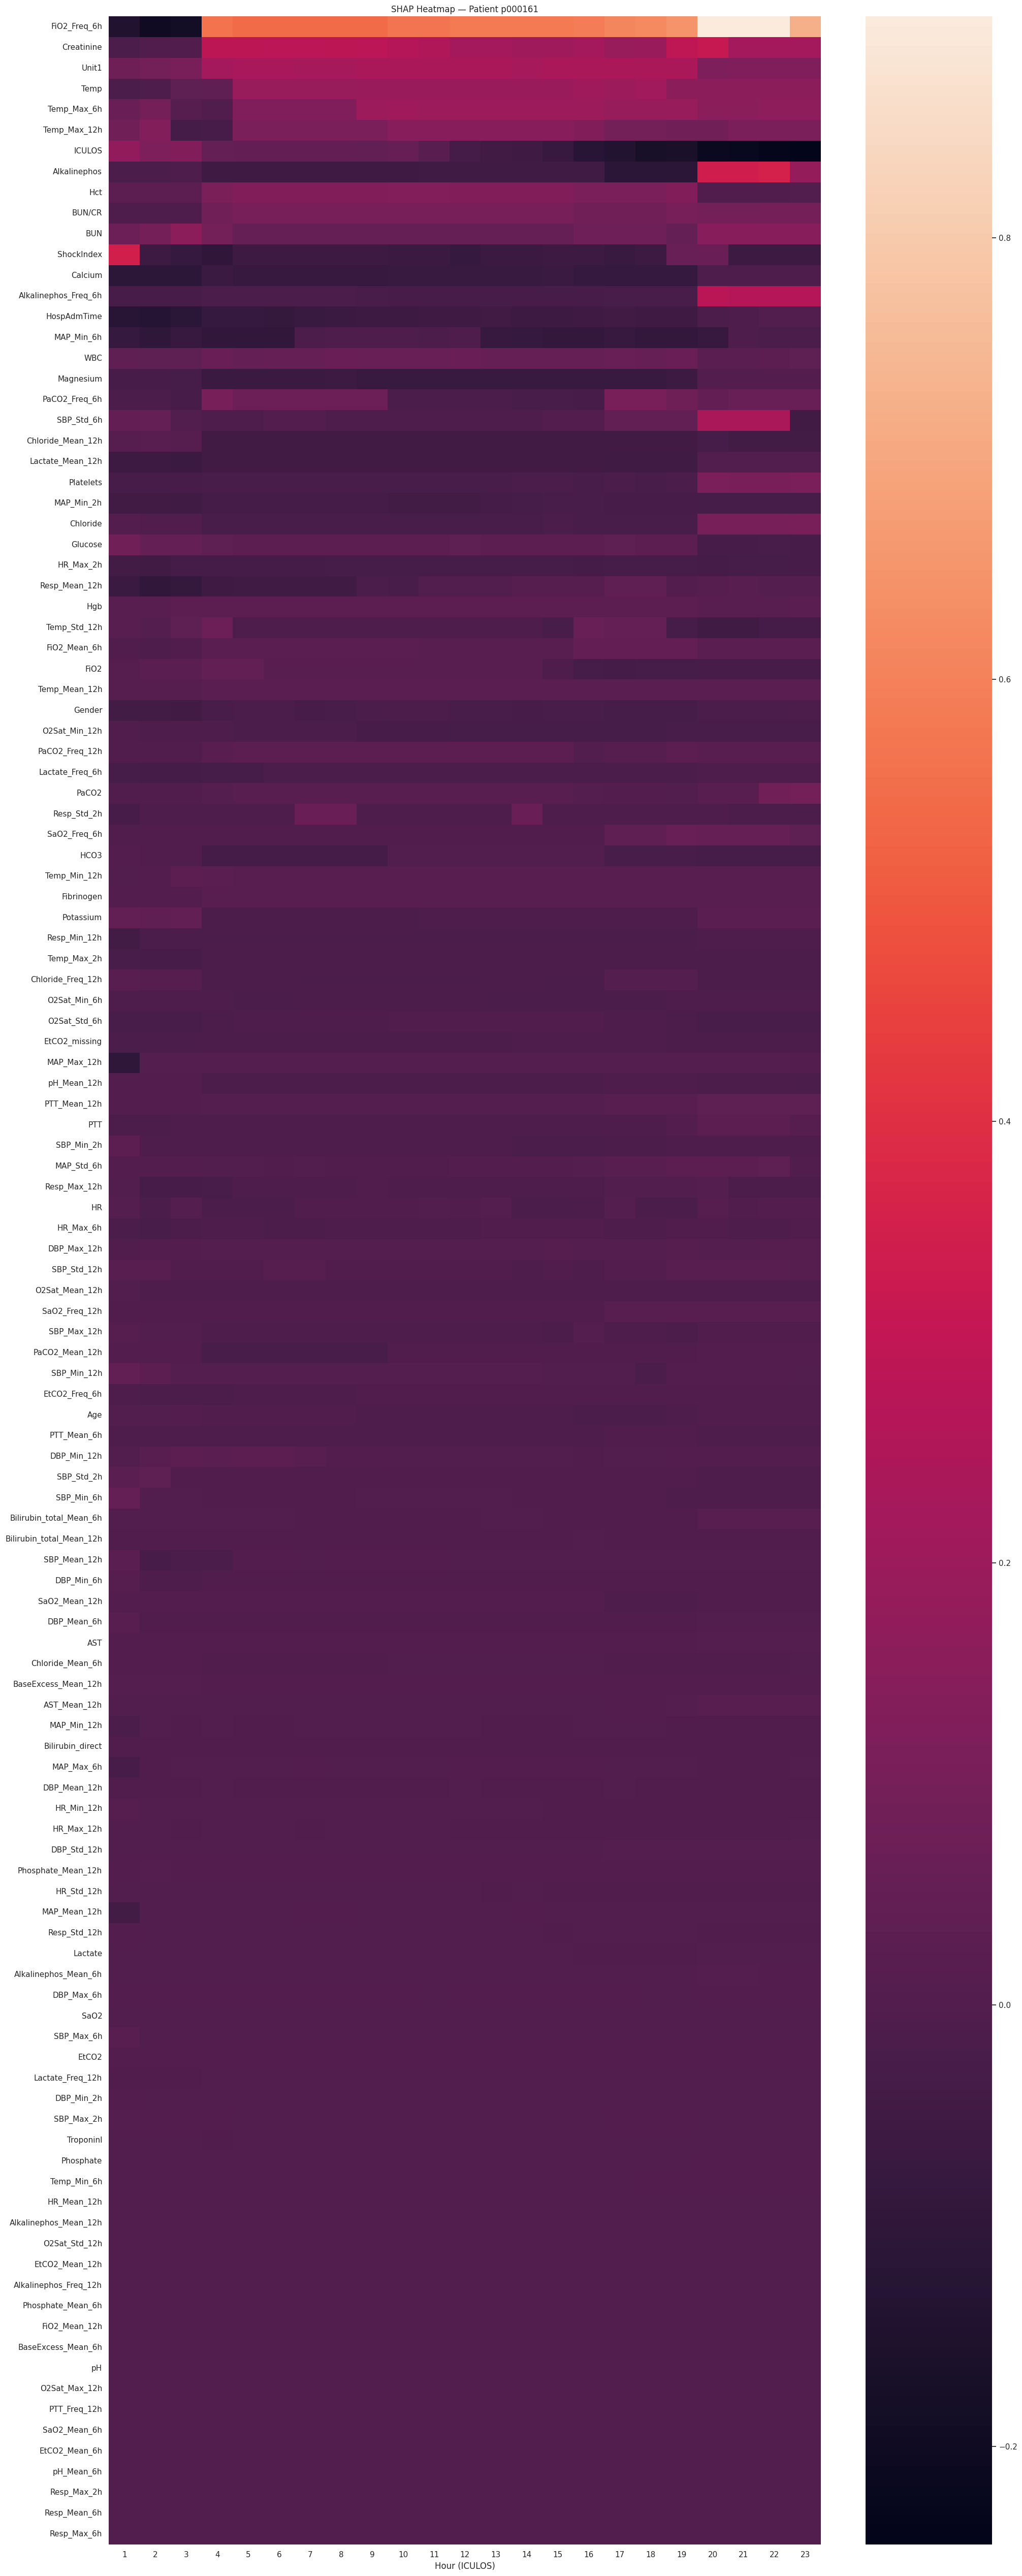

In [52]:
plot_shap_heatmap(sv, patient_id='p000161', top_k=122, filename='shap_heatmap_p000161_all_features.svg')

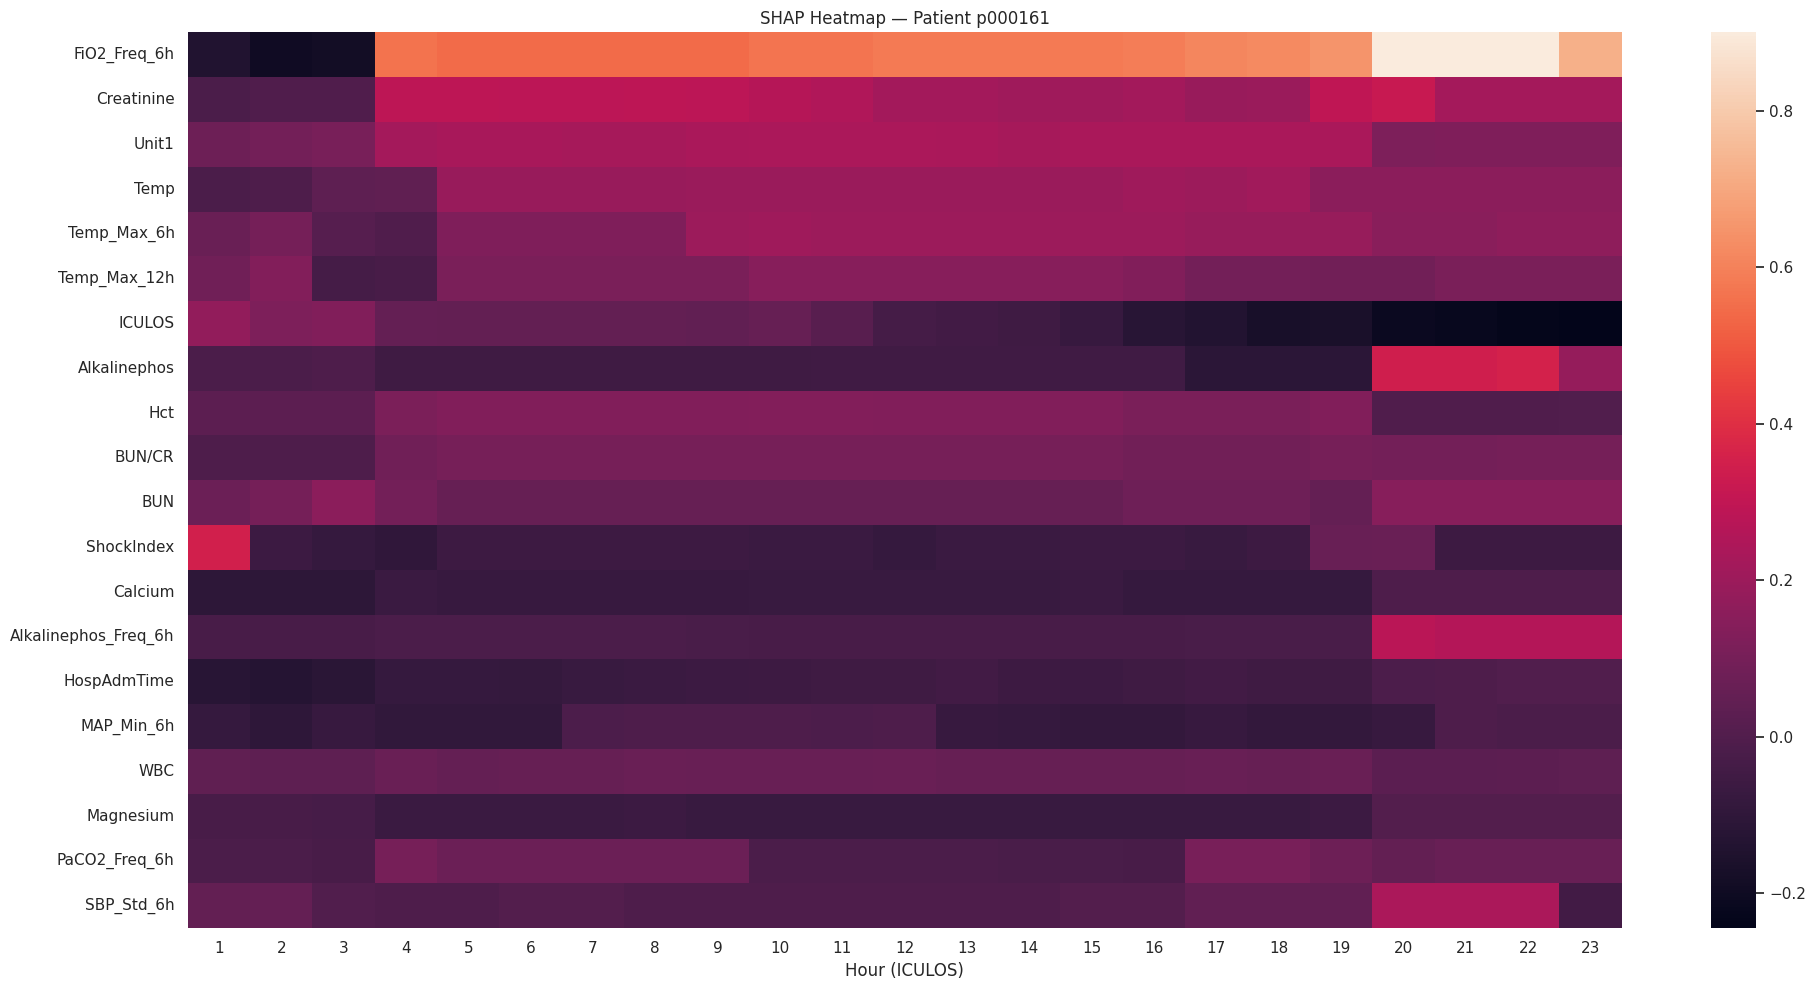

In [53]:
plot_shap_heatmap(sv, patient_id='p000161', top_k=20, filename='shap_heatmap_p000161_top_20.svg')

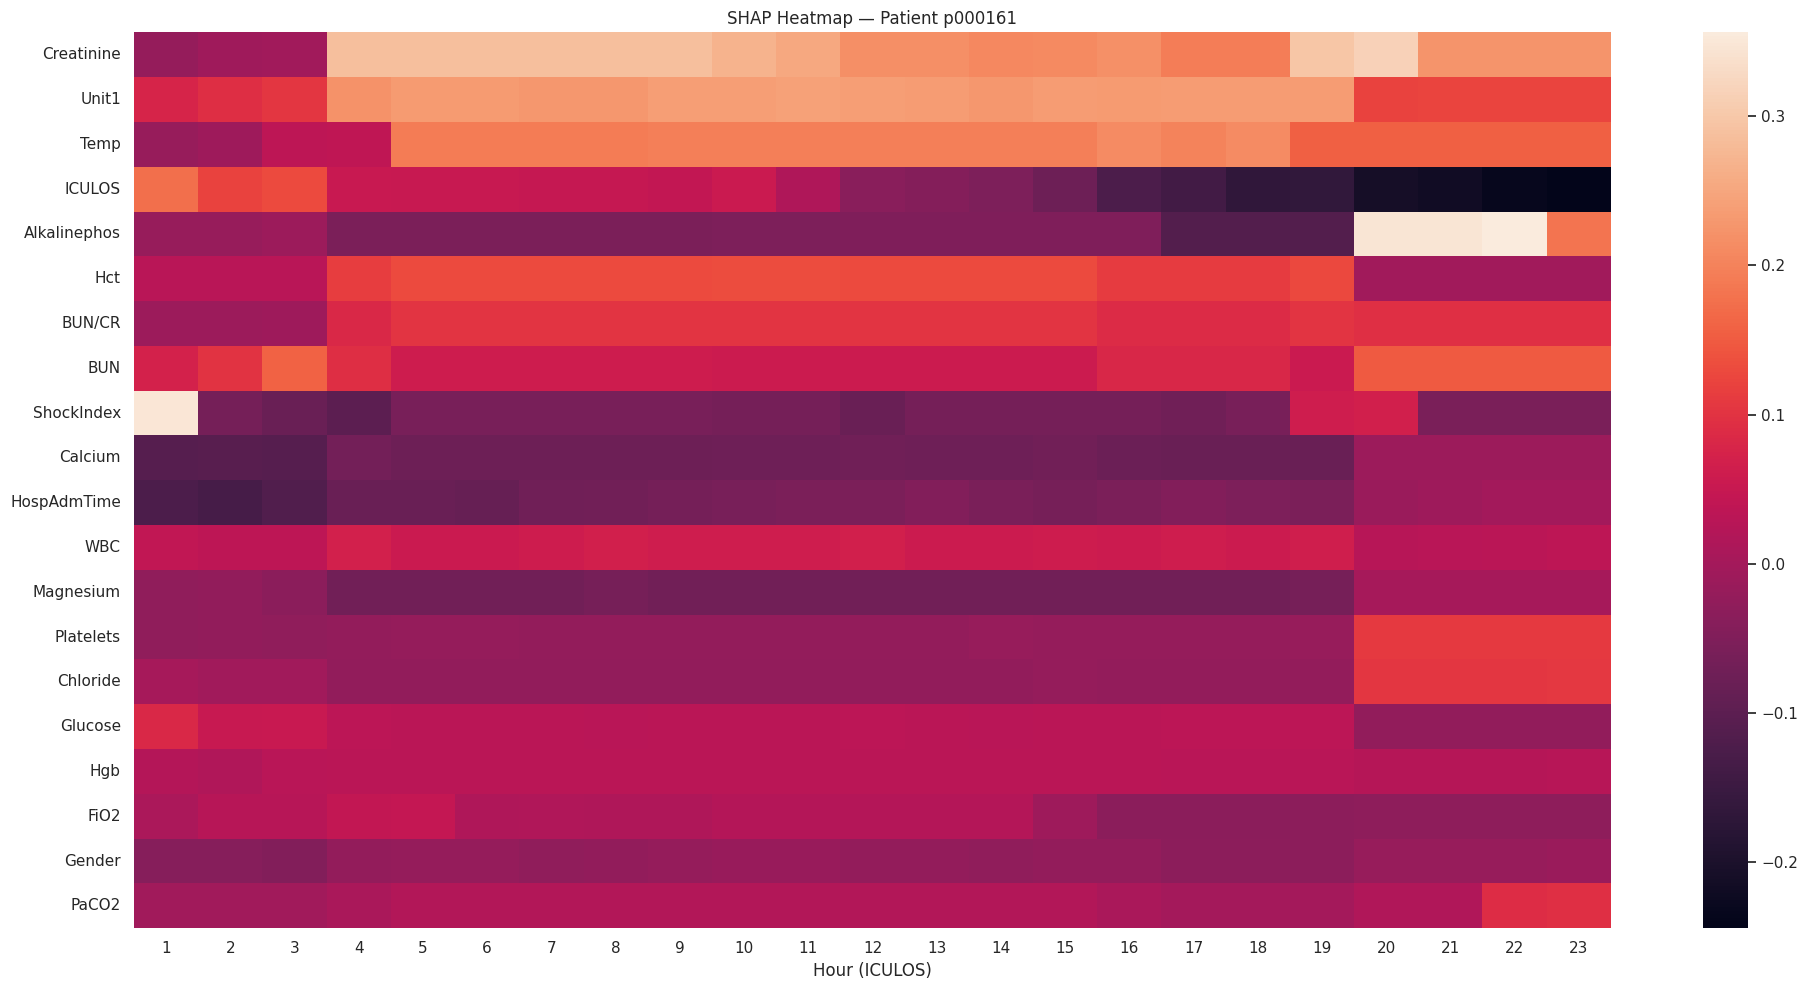

In [54]:
plot_shap_heatmap(sv, patient_id='p000161', top_k=20, show_missing=False, show_windows=False, filename='shap_heatmap_p000161_top_20_original_features.svg')

In [55]:
def plot_local_shap(shap_values, hour, color_func, colors_dict, filename=None,
                    top_k=15, show_missing=True, show_windows=True):
    values = shap_values.values
    all_names = shap_values.feature_names
    idx = list(range(len(all_names)))
    if not show_missing:
        idx = [i for i in idx if '_missing' not in all_names[i]]
    if not show_windows:
        idx = [i for i in idx if not re.search(r'_\d+h$', all_names[i])]
    values = values[:, idx]
    feature_names = [all_names[i] for i in idx]
    hour_importance = values[hour]
    top_idx = np.argsort(np.abs(hour_importance))[::-1][:top_k]
    top_names = [feature_names[i] for i in top_idx][::-1]
    top_values = hour_importance[top_idx][::-1]
    colors = [color_func(f) for f in top_names]
    plt.rcParams.update({
        'font.size': 10,
        'font.family': 'sans-serif',
        'font.weight': 'normal',
        'axes.labelweight': 'normal'
    })

    fig, ax = plt.subplots(figsize=(10, 6), facecolor='white')
    bars = ax.barh(top_names, top_values, color=colors, edgecolor='#333333', linewidth=0.6)
    
    for bar, val in zip(bars, top_values):
        width = bar.get_width()
        if val >= 0:
            ax.text(width + 0.005, bar.get_y() + bar.get_height()/2,
                    f'+{width:.3f}', va='center', ha='left', fontsize=9, color='black')
        else:
            ax.text(width - 0.005, bar.get_y() + bar.get_height()/2,
                    f'{width:.3f}', va='center', ha='right', fontsize=9, color='black')

    xmin, xmax = ax.get_xlim()
    ax.set_xlim(xmin - 0.05, xmax + 0.05)
    ax.set_xlabel('Impact on sepsis probability', fontsize=11, labelpad=10, color='black')
    ax.set_ylabel('Features', fontsize=11, labelpad=5, color='black')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('black')
    ax.spines['left'].set_linewidth(0.8)
    ax.spines['bottom'].set_color('black')
    ax.spines['bottom'].set_linewidth(0.8)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.tick_params(axis='both', colors='black', labelsize=10)
    ax.grid(True, axis='x', linestyle='-', color='black', alpha=0.08, linewidth=0.5)
    ax.set_axisbelow(True)
    # xmin = min(top_values.min(), 0) 
    # xmax = max(top_values.max(), 0)
    # padding = (xmax - xmin) * 0.2
    # ax.set_xlim(xmin - padding, xmax + padding)
    legend = [Patch(color=v, label=k) for k, v in colors_dict.items()]
    ax.legend(handles=legend, loc='lower right', frameon=True, edgecolor='black', fontsize=9)
    plt.tight_layout()
    if filename:
        plt.savefig(filename, bbox_inches='tight', dpi=300, facecolor='white')
    plt.show()

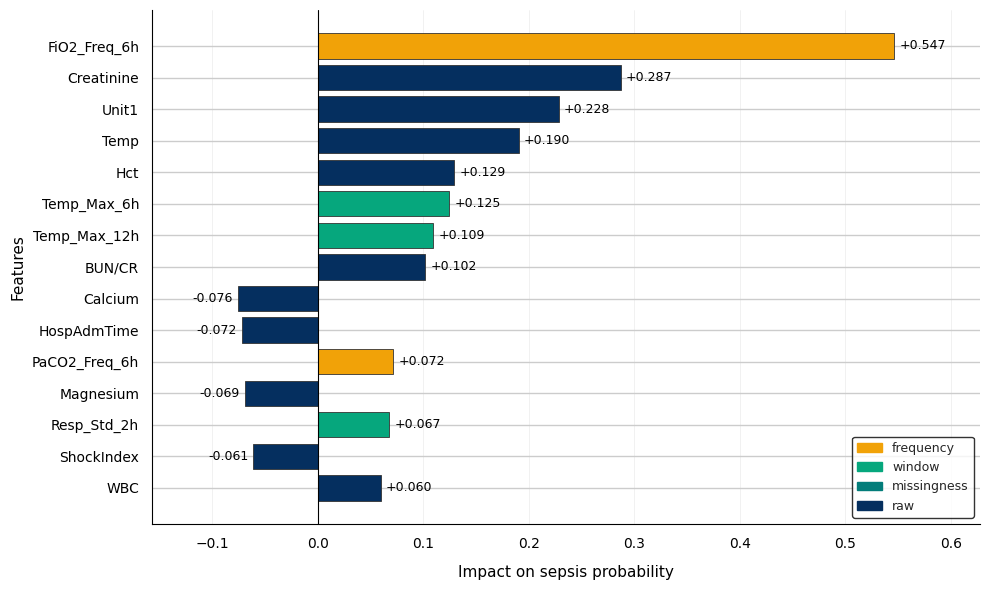

In [56]:
plot_local_shap(sv, hour=6, color_func=get_color_v1, colors_dict=colors_v1, filename='local_shap_p000161_hour6.svg')

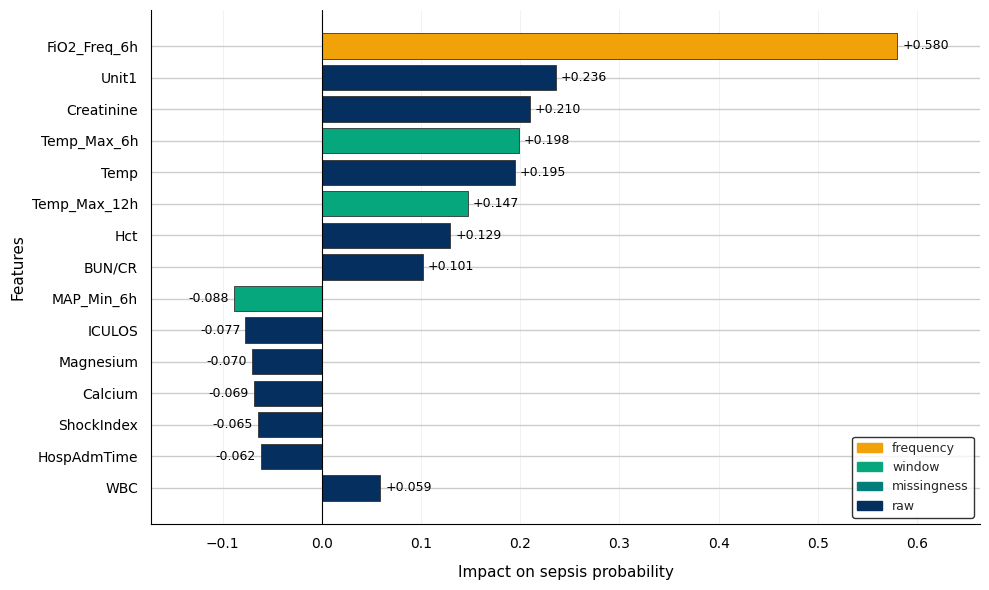

In [57]:
plot_local_shap(sv, hour=14, color_func=get_color_v1, colors_dict=colors_v1, filename='local_shap_p000161_hour14.svg')

### Non-septic patient p000001

In [58]:
sv_non_septic = explainer(patient_non_septic)

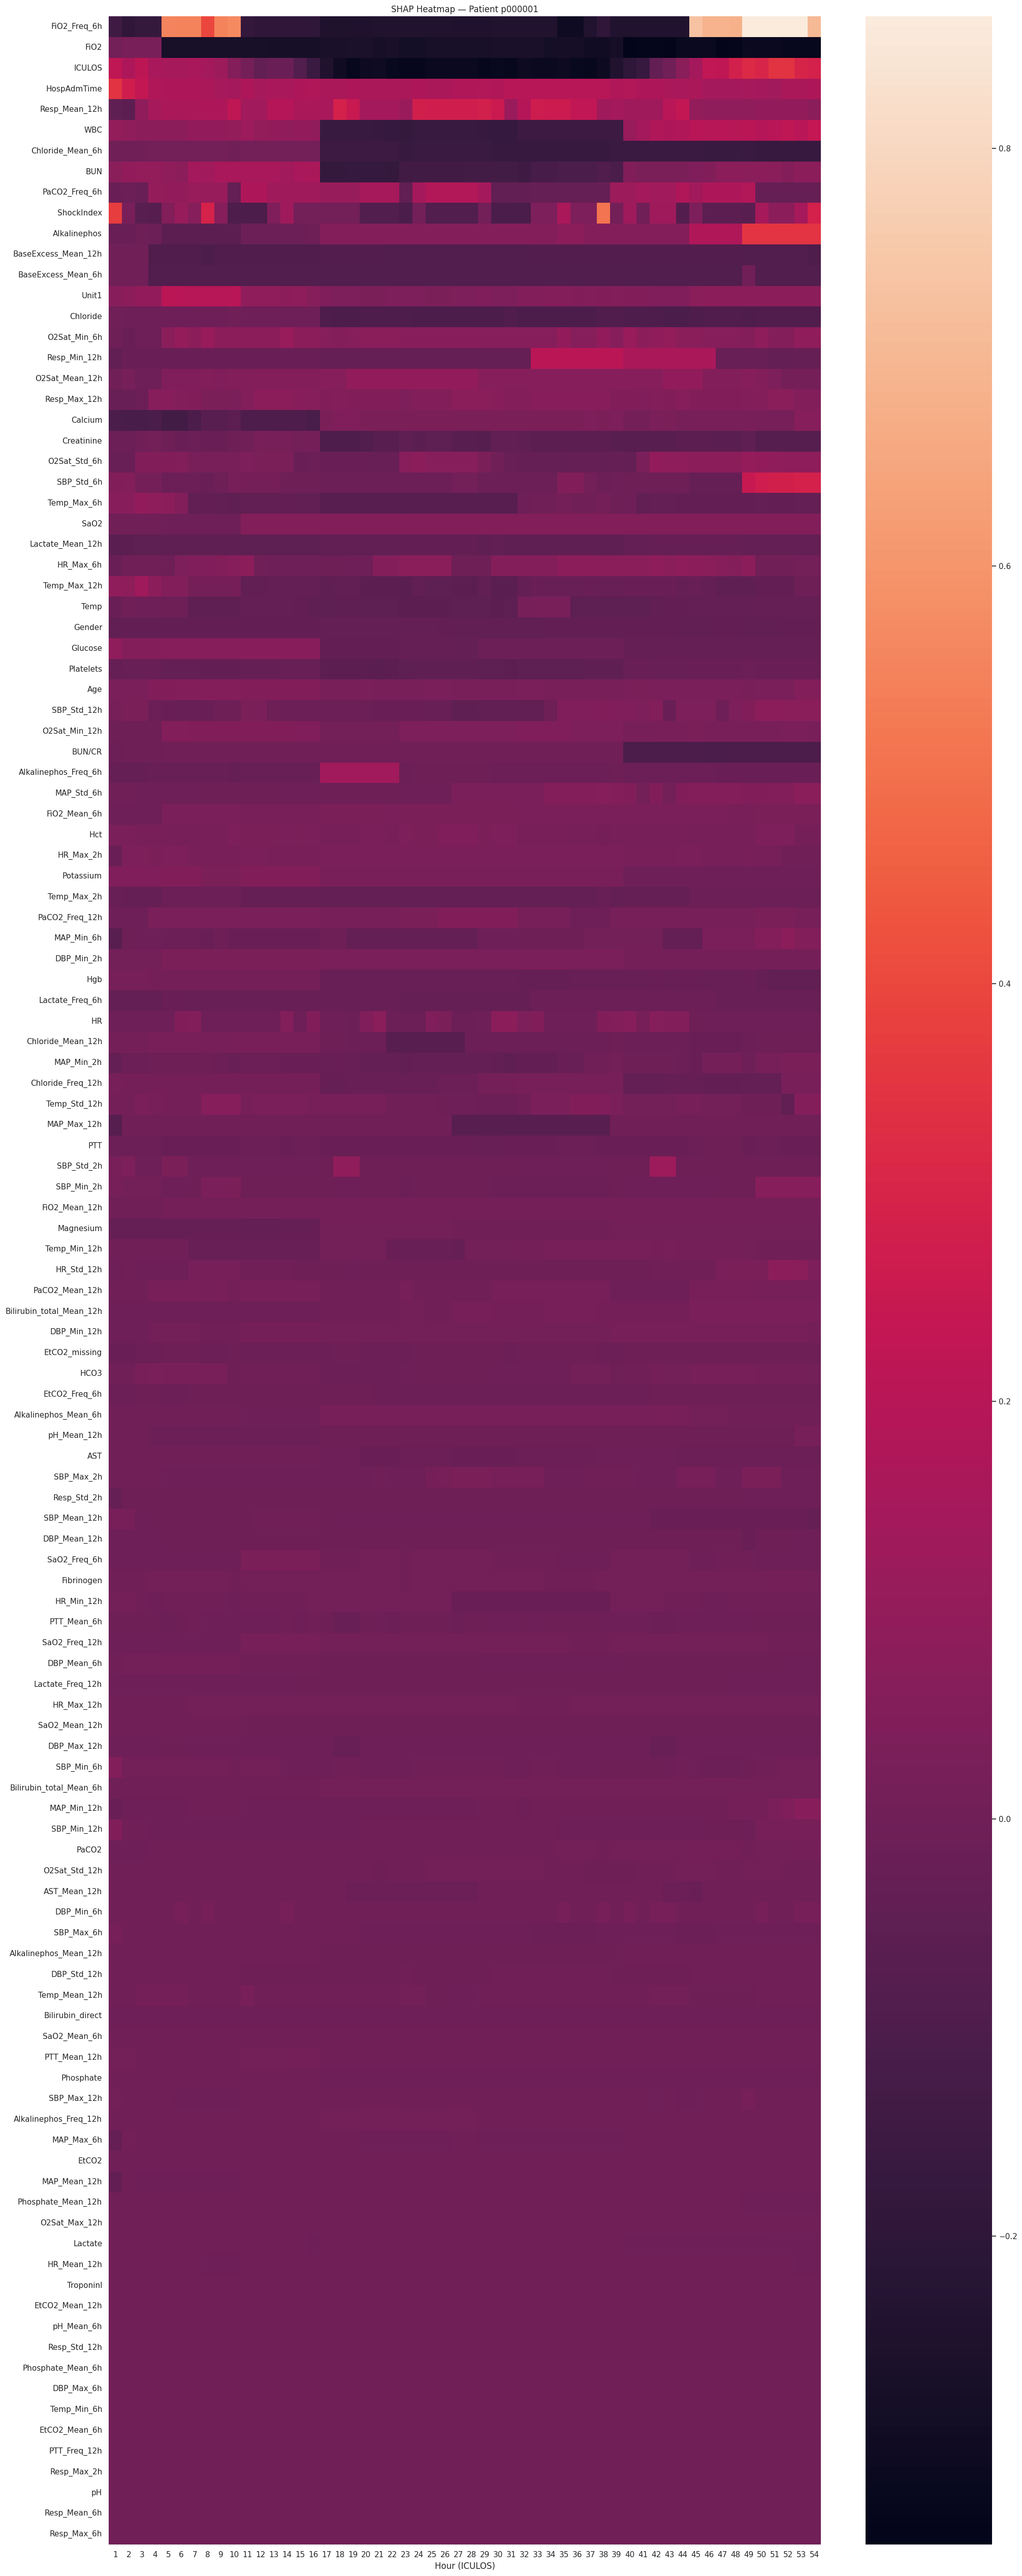

In [59]:
plot_shap_heatmap(sv_non_septic, patient_id='p000001', top_k=122, filename='shap_heatmap_p000001_all_features.svg')

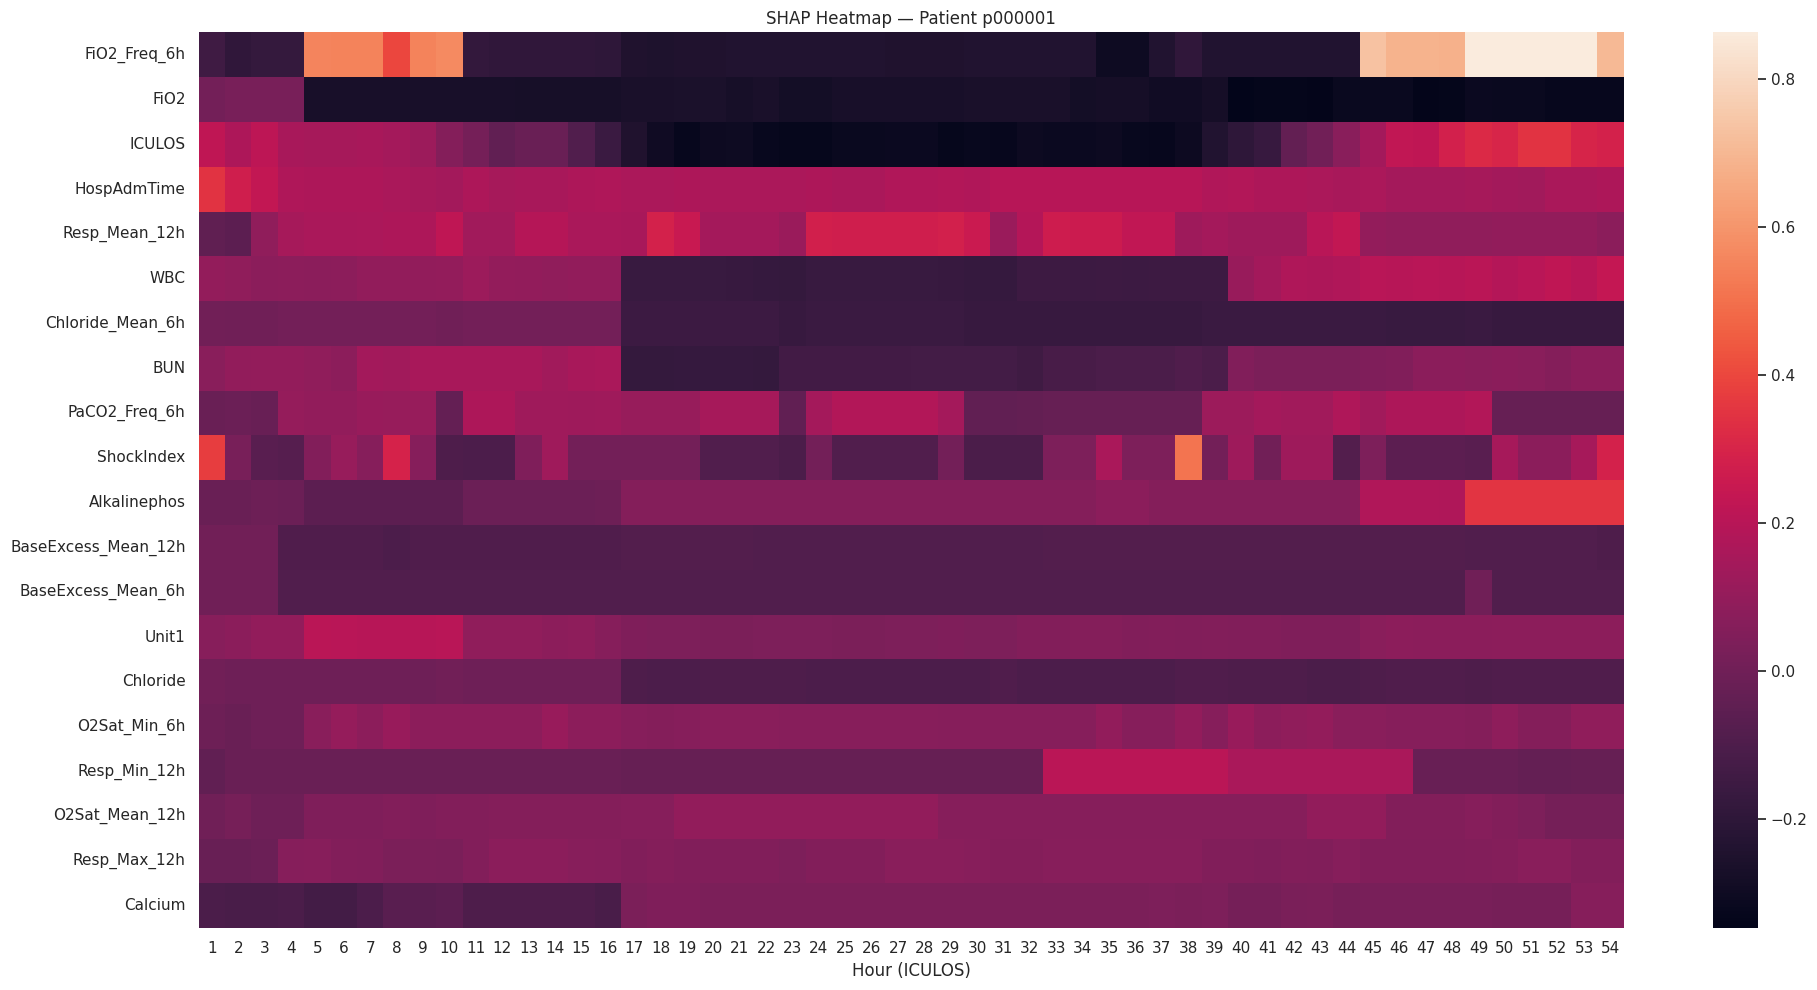

In [60]:
plot_shap_heatmap(sv_non_septic, patient_id='p000001', top_k=20, filename='shap_heatmap_p000001_top_20.svg')

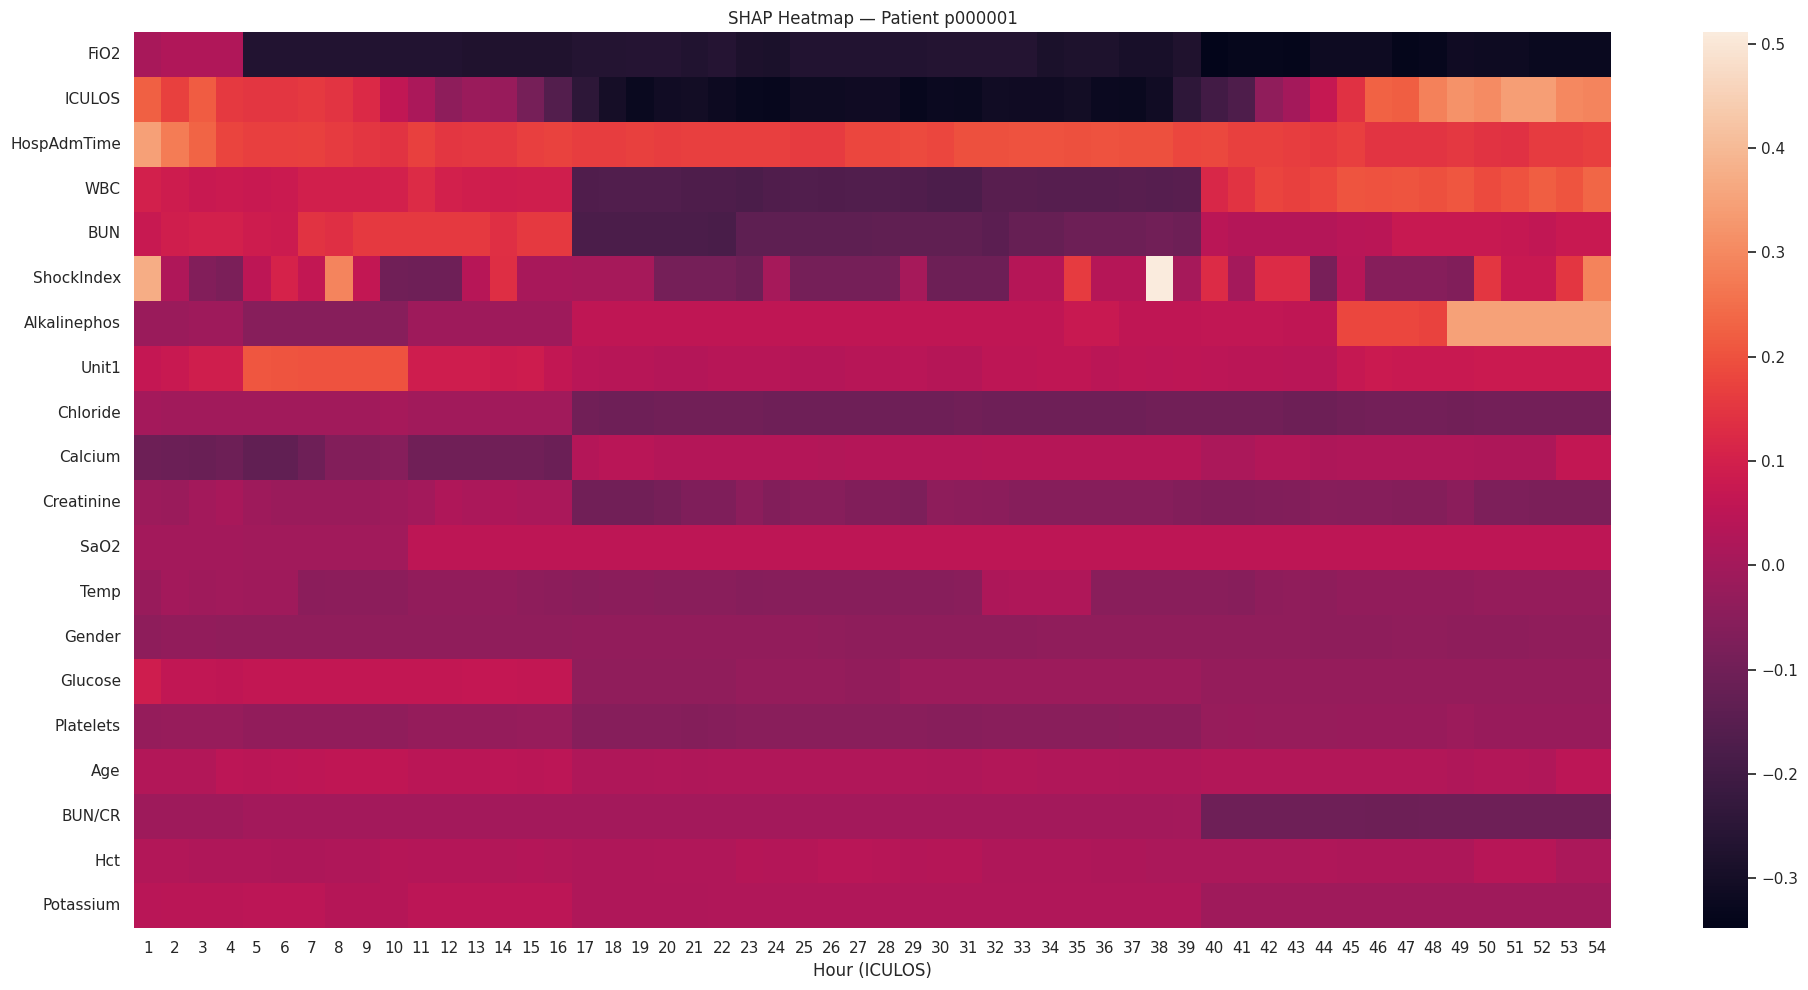

In [61]:
plot_shap_heatmap(sv_non_septic, patient_id='p000001', top_k=20, show_missing=False, show_windows=False, filename='shap_heatmap_p000001_top_20_original_features.svg')

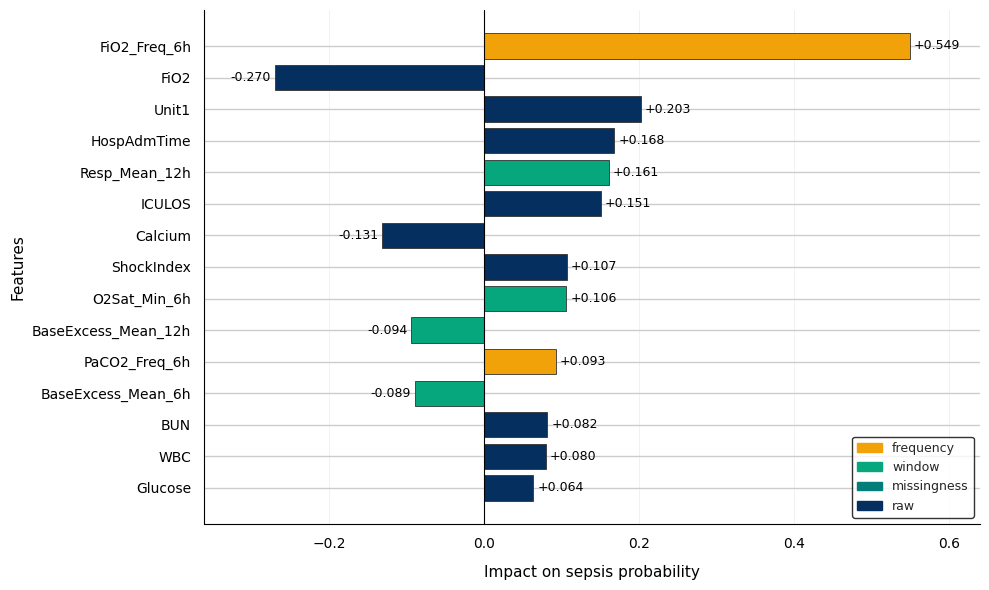

In [62]:
plot_local_shap(sv_non_septic, hour=5, color_func=get_color_v1, colors_dict=colors_v1, filename='local_shap_p000001_hour5.svg')

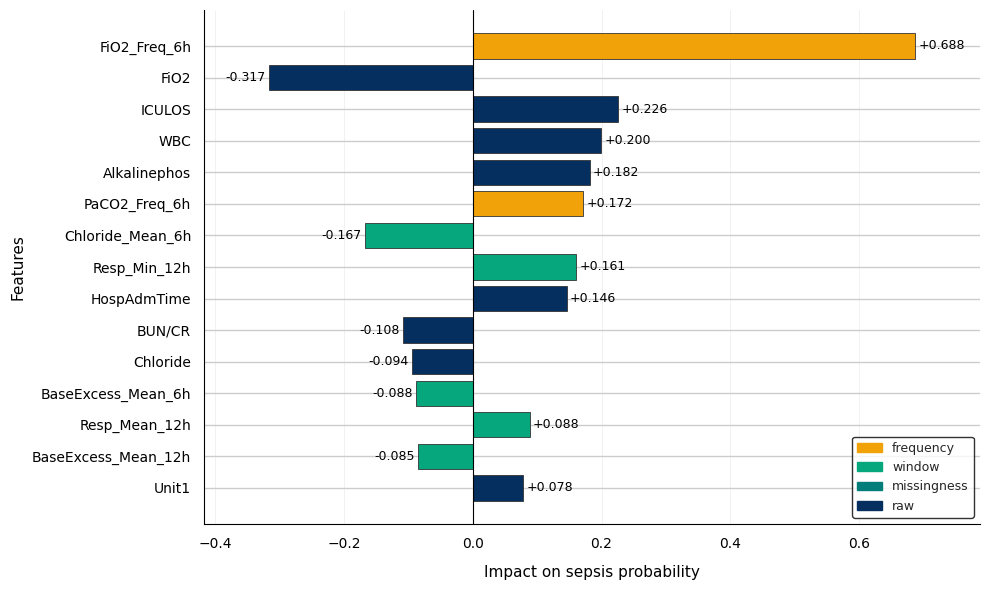

In [63]:
plot_local_shap(sv_non_septic, hour=45, color_func=get_color_v1, colors_dict=colors_v1, filename='local_shap_p000001_hour45.svg')